In [1]:
import gymnasium as gym
import ale_py

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pyvirtualdisplay import Display

%matplotlib inline

In [ ]:
env_name = "ALE/MsPacman-v5"

env = gym.make(env_name, render_mode="rgb_array")

A.L.E: Arcade Learning Environment (version 0.12.0+0706845)
[Powered by Stella]


### Exploring the environment

In [3]:
env.action_space

Discrete(9)

In [4]:
list(range(env.action_space.n))

[0, 1, 2, 3, 4, 5, 6, 7, 8]

In [11]:
for i in range(10):
    print(str(i) + ": ", env.action_space.sample())

0:  6
1:  2
2:  2
3:  2
4:  4
5:  0
6:  5
7:  4
8:  4
9:  6


Action space is a (9,) vector then. With discrete actions being lit up.

In [5]:
env.observation_space

Box(0, 255, (210, 160, 3), uint8)

So the observation space is 210x160 3-channel array with values between 0-255 in RGB array mode

In [6]:
obs, info = env.reset()

In [7]:
info

{'lives': 3, 'episode_frame_number': 0, 'frame_number': 0}

In [ ]:
plt.imshow(obs)

### Reshaping the observation

0 0.0 False False {'lives': 3, 'episode_frame_number': 264, 'frame_number': 2424}


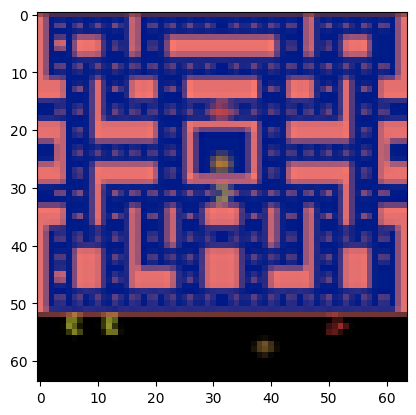

In [18]:
from PIL import Image
env_64 = gym.wrappers.ResizeObservation(env, (84, 65))

# obs, info  = env_64.reset()

sample_act = env.action_space.sample()
obs, reward, truncated, terminated, info = env_64.step(sample_act)
print(sample_act, reward, truncated, terminated, info)

obs = Image.fromarray(obs)
plt.imshow(obs.resize((64, 64)))        # Resizing keeping the frame aspect ratio

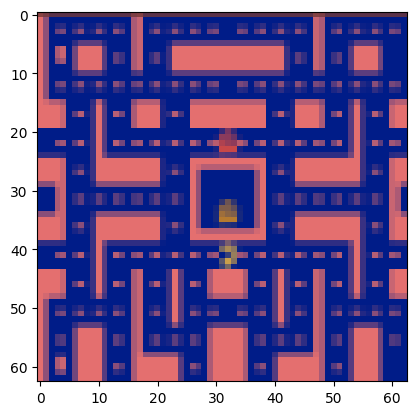

In [21]:
# Cropping the observation
obs = obs.crop((0, 0, 63, 63))
plt.imshow(obs)

### Recording and Evaluating rollouts

In [ ]:
num_eval_eps = 5

env_rec = gym.wrappers.RecordVideo(
    env, 
    video_folder="./videos/examples/",
    name_prefix="test-video"
)
env_rec = gym.wrappers.RecordEpisodeStatistics(
    env_rec, buffer_length=num_eval_eps
)

rewards_hist = []

/home/utkarsh/active_projects/world-models/.venv/lib/python3.10/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/utkarsh/active_projects/world-models/videos/examples folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [29]:
for ep_num in range(num_eval_eps):
    obs, info = env_rec.reset()
    ep_reward = 0
    step_count = 0
    
    while True:
        action = env_rec.action_space.sample()
        obs, reward, terminated, truncated, info= env_rec.step(action)
        
        ep_reward += float(reward)
        step_count += 1
        
        if (terminated or truncated): break
    
    print(f"Episode {ep_num + 1}: {step_count} steps, reward = {ep_reward}")

env_rec.close()

# Print summary statistics
print(f'\nEvaluation Summary:')
print(f'Episode durations: {list(env_rec.time_queue)}')
print(f'Episode rewards: {list(env_rec.return_queue)}')
print(f'Episode lengths: {list(env_rec.length_queue)}')

# Calculate some useful metrics
avg_reward = np.mean(env_rec.return_queue)
avg_length = np.sum(env_rec.length_queue)
std_reward = np.std(env_rec.return_queue)

print(f'\nAverage reward: {avg_reward:.2f} ± {std_reward:.2f}')
print(f'Average episode length: {avg_length:.1f} steps')
print(f'Success rate: {sum(1 for r in env_rec.return_queue if r > 0) / len(env_rec.return_queue):.1%}')


Episode 1: 535 steps, reward = 220.0
Episode 2: 523 steps, reward = 310.0
Episode 3: 503 steps, reward = 330.0
Episode 4: 721 steps, reward = 270.0
Episode 5: 545 steps, reward = 330.0

Evaluation Summary:
Episode durations: [0.860238, 0.51254, 0.42188, 0.655216, 0.526021]
Episode rewards: [220.0, 310.0, 330.0, 270.0, 330.0]
Episode lengths: [535, 523, 503, 721, 545]

Average reward: 292.00 ± 42.14
Average episode length: 2827.0 steps
Success rate: 100.0%


### Checking `env.reset()` multiple times

In [4]:
env = gym.make(env_name, render_mode="rgb_array")

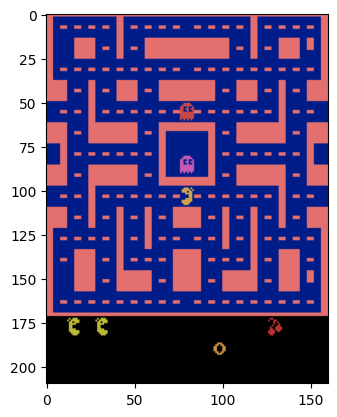

In [27]:
obs, info = env.reset()
plt.imshow(obs)

## Checking the NoOp on Reset

Whenever I'm visualizing MsPacman, it seems that for the couple of frames, even though there's a control signal being sent, there are no changes in the actual environment. I need to probe it first.

In [15]:
env_rec = gym.wrappers.RecordVideo(
    env, 
    video_folder="./videos/examples/",
    name_prefix="test-video-trial"
)
env_rec = gym.wrappers.RecordEpisodeStatistics(env_rec)

rewards_hist = []

/home/utkarsh/active_projects/world-models/.venv/lib/python3.10/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/utkarsh/active_projects/world-models/videos/examples folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [16]:
obs, info = env_rec.reset()
prev_obs = obs.copy()

frame_idx = 0
for frame_idx in range(65):
    action = env_rec.action_space.sample()
    obs, reward, terminated, truncated, info = env_rec.step(action)
    # diff = np.abs(obs.astype(int) - prev_obs.astype(int)).sum()
    # print(frame_idx, diff, action, info.get("lives"))
    print(frame_idx, action, info.get("lives"))
    prev_obs = obs.copy()
    
    if (terminated or truncated): break

env_rec.close()

0 0 3
1 8 3
2 3 3
3 4 3
4 6 3
5 1 3
6 4 3
7 3 3
8 6 3
9 8 3
10 5 3
11 6 3
12 5 3
13 2 3
14 0 3
15 4 3
16 2 3
17 8 3
18 0 3
19 7 3
20 1 3
21 4 3
22 1 3
23 8 3
24 1 3
25 7 3
26 2 3
27 3 3
28 2 3
29 7 3
30 5 3
31 8 3
32 0 3
33 3 3
34 6 3
35 1 3
36 4 3
37 2 3
38 0 3
39 8 3
40 0 3
41 8 3
42 8 3
43 3 3
44 0 3
45 4 3
46 4 3
47 6 3
48 1 3
49 1 3
50 4 3
51 5 3
52 1 3
53 5 3
54 1 3
55 1 3
56 1 3
57 3 3
58 6 3
59 7 3
60 4 3
61 3 3
62 7 3
63 5 3
64 2 3
